# causal/01 PSM 倾向得分匹配 实战

数据：MovieLens 1M（grouplens.org 公开下载）
目标：用 PSM 估计推荐 v2 时期的因果效应

三步法：
1. logistic 回归估计倾向得分
2. 1:4 NN + 卡尺匹配
3. SMD + 倾向得分密度图平衡性检验

本文用 2000 用户样本加速演示；完整数据跑法注释里写明。

In [1]:
import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd

# Resolve repo root from either common launch dir: nbconvert runs with cwd = the
# notebook's own dir (notebooks/); an interactive Jupyter server may start at the
# repo root. Pick whichever ancestor actually holds data/ml-1m. If neither, point
# PSM_DATA straight at the data dir.
# Example: PSM_DATA='D:/Workspace/ml-learning/data/ml-1m'
REPO_ROOT = Path.cwd().parent if (Path.cwd().parent / 'data' / 'ml-1m').exists() else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))  # so `from models.propensity_score_matching import ...` resolves
DATA_DIR = os.environ.get('PSM_DATA', str(REPO_ROOT / 'data' / 'ml-1m'))

def load_movielens_1m(data_dir):
    """Load MovieLens 1M and compute user-level features.

    Parameters
    ----------
    data_dir : str
        Path to directory containing ratings.dat, users.dat, movies.dat.

    Returns
    -------
    pd.DataFrame
        One row per (user_id, item_id, timestamp) with confounder columns.
    """
    ratings = pd.read_csv(
        os.path.join(data_dir, 'ratings.dat'),
        sep='::', engine='python',
        names=['user_id', 'item_id', 'rating', 'timestamp'],
        encoding='latin-1')
    users = pd.read_csv(
        os.path.join(data_dir, 'users.dat'),
        sep='::', engine='python',
        names=['user_id', 'gender', 'age', 'occupation', 'zip'],
        encoding='latin-1')
    movies = pd.read_csv(
        os.path.join(data_dir, 'movies.dat'),
        sep='::', engine='python',
        names=['item_id', 'title', 'genres'],
        encoding='latin-1')

    movies['genre_list'] = movies['genres'].str.split('|')
    ratings = ratings.merge(movies[['item_id', 'genre_list']], on='item_id')

    user_feats = ratings.groupby('user_id').agg(
        n_ratings=('rating', 'count'),
        rating_std=('rating', 'std'),
        genre_set=('genre_list', lambda x: set(g for lst in x for g in lst)),
    ).reset_index()
    user_feats['genre_diversity'] = user_feats['genre_set'].apply(len)
    user_feats = user_feats.drop(columns=['genre_set'])

    df = ratings.merge(user_feats, on='user_id')
    df = df.merge(users, on='user_id')

    cutoff = df['timestamp'].quantile(0.80)
    df['period'] = (df['timestamp'] > cutoff).astype(int)

    df['rating_std'] = df['rating_std'].fillna(0)

    return df

df = load_movielens_1m(DATA_DIR)

# Sample 2000 users for speed (full run: remove sampling)
np.random.seed(42)
sampled_users = np.random.choice(df['user_id'].unique(), 2000, replace=False)
df_small = df[df['user_id'].isin(sampled_users)].copy()
print(f'Sampled: {len(df_small)} rows, {df_small["user_id"].nunique()} users')
print(df_small[['user_id', 'rating', 'period', 'n_ratings', 'genre_diversity', 'rating_std', 'age']].head())


Sampled: 326413 rows, 2000 users
     user_id  rating  period  n_ratings  genre_diversity  rating_std  age
693        9       4       1        106               17     0.82001   25
694        9       4       1        106               17     0.82001   25
695        9       3       1        106               17     0.82001   25
696        9       2       1        106               17     0.82001   25
697        9       4       1        106               17     0.82001   25


## 数据概览

v1 = timestamp 前 80% 的评分，v2 = 后 20%。公开数据集没有「v2 上线」标签，这是公开数据集的局限，真实业务里 v1/v2 由上线时间直接划分。

In [2]:
print('=== Period distribution ===')
print(df_small['period'].value_counts())
print()
print('=== Confounder means by period ===')
for col in ['n_ratings', 'genre_diversity', 'rating_std', 'age']:
    m_v1 = df_small[df_small['period']==0][col].mean()
    m_v2 = df_small[df_small['period']==1][col].mean()
    print(f'  {col}: v1={m_v1:.2f}, v2={m_v2:.2f}')

=== Period distribution ===
period
0    257743
1     68670
Name: count, dtype: int64

=== Confounder means by period ===
  n_ratings: v1=358.54, v2=430.44
  genre_diversity: v1=16.95, v2=17.17
  rating_std: v1=1.02, v2=1.00


  age: v1=29.96, v2=27.88


## 朴素估计：v2 vs v1 直接比较

这是业务组看到 30% 的源头。但这里没剥离 confounder，估计值包含：
1. v2 推荐系统本身的因果效应
2. v2 时期与 v1 时期用户在 confounder 上的差异

In [3]:
v1_mean = df_small[df_small['period']==0]['rating'].mean()
v2_mean = df_small[df_small['period']==1]['rating'].mean()
naive_effect = v2_mean - v1_mean
print(f'v1 mean rating: {v1_mean:.4f}')
print(f'v2 mean rating: {v2_mean:.4f}')
print(f'Naive effect (v2 - v1): {naive_effect:+.4f}')

v1 mean rating: 3.5886
v2 mean rating: 3.5505
Naive effect (v2 - v1): -0.0380


## Step 1：logistic 回归估计倾向得分

特征是用户层面的 confounder：
- `n_ratings`: 用户评分次数（活跃度）
- `genre_diversity`: 用户评分过的电影品类数（偏好多样性）
- `rating_std`: 用户评分标准差（评分极性）
- `age`: 年龄段
- `gender`: 性别（编码为 0/1）

模型输出每个用户在 v2 时期的概率。

In [4]:
from models.propensity_score_matching import PropensityScoreMatching

df_small['gender_num'] = (df_small['gender'] == 'M').astype(int)
feature_cols = ['n_ratings', 'genre_diversity', 'rating_std', 'age', 'gender_num']

# Collapse to user-level: one row per (user_id, period), take mean propensity later
user_level = df_small.groupby(['user_id', 'period']).first().reset_index()
user_level['mean_rating'] = df_small.groupby(['user_id', 'period'])['rating'].mean().values

X = user_level[feature_cols].values
T = user_level['period'].values

# Fit PSM (internally runs logistic + computes caliper)
psm = PropensityScoreMatching(k=4, caliper_factor=0.2)
psm.fit(X, T)
user_level['propensity'] = psm.propensity_

print(f'Users: {len(user_level)}, v1: {(T==0).sum()}, v2: {(T==1).sum()}')
print(f'Propensity range: [{user_level["propensity"].min():.4f}, {user_level["propensity"].max():.4f}]')
print(f'Mean propensity: {user_level["propensity"].mean():.4f}')

Users: 2354, v1: 1757, v2: 597
Propensity range: [0.0960, 0.6174]
Mean propensity: 0.2536


## Step 2：1:4 NN 匹配 + 卡尺

每个 v2 用户找 4 个 v1 用户，倾向得分最接近的。卡尺 = 0.2 × PS 标准差，过滤掉倾向得分距离太远的配对。卡尺外的 v2 用户不进入匹配（PSM 实践中的常见处理）。

In [5]:
matched_pairs = psm.match(T, user_ids=user_level['user_id'].values)
print(f'Caliper threshold: {psm.caliper_:.4f}')
matched_uids = set()
for t_uid, c_uid in matched_pairs:
    matched_uids.add(int(t_uid))
    matched_uids.add(int(c_uid))

matched_df = df_small[df_small['user_id'].isin(matched_uids)].copy()
print(f'Matched users: {len(set(int(u) for t, c in matched_pairs for u in [t, c]))}')
print(f'Matched rating rows: {len(matched_df)} (from {len(df_small)})')
print(f'Matched period counts: {matched_df["period"].value_counts().to_dict()}')

Caliper threshold: 0.0152
Matched users: 1508
Matched rating rows: 276557 (from 326413)
Matched period counts: {0: 209682, 1: 66875}


## Step 3：平衡性检验（SMD）

SMD = 标准化均值差（Standardized Mean Difference）：

SMD = |X_t - X_c| / sqrt((s_t^2 + s_c^2) / 2)

经验阈值：SMD < 0.1 视为平衡。

In [6]:
matched_uids_t = set(int(t) for t, c in matched_pairs)
matched_uids_c = set(int(c) for t, c in matched_pairs)

# SMD before matching: across all users
df_t_full = user_level[user_level['period'] == 1]
df_c_full = user_level[user_level['period'] == 0]

# SMD after matching: only matched users
df_t_mat = user_level[user_level['user_id'].isin(matched_uids_t) & (user_level['period'] == 1)]
df_c_mat = user_level[user_level['user_id'].isin(matched_uids_c) & (user_level['period'] == 0)]

def compute_smd(df_t, df_c, feature_cols):
    smd = {}
    for col in feature_cols:
        t_mean = df_t[col].mean()
        c_mean = df_c[col].mean()
        pooled = np.sqrt((df_t[col].var() + df_c[col].var()) / 2)
        smd[col] = abs(t_mean - c_mean) / pooled if pooled > 0 else 0
    return smd

smd_before = compute_smd(df_t_full, df_c_full, feature_cols)
smd_after  = compute_smd(df_t_mat, df_c_mat, feature_cols)

print(f'{"Confounder":<20} {"SMD before":>12} {"SMD after":>12}')
print('-' * 46)
for col in feature_cols:
    flag = '*' if smd_before[col] >= 0.1 else ' '
    print(f'{col:<20} {smd_before[col]:>12.4f}{flag} {smd_after[col]:>12.4f}')

Confounder             SMD before    SMD after


----------------------------------------------
n_ratings                  0.3624*       0.2153
genre_diversity            0.2961*       0.1535
rating_std                 0.0876        0.0489
age                        0.0610        0.0338
gender_num                 0.0648        0.0234


## 倾向得分密度：匹配前 vs 匹配后

匹配前 v1/v2 的倾向得分分布错位（v2 用户倾向得分更高），匹配后两组分布基本重叠。

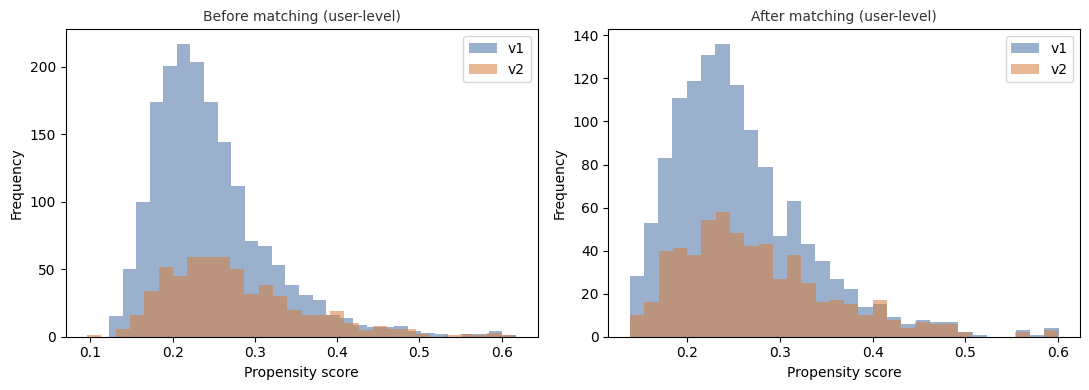

In [7]:
import matplotlib.pyplot as plt
import os
from pathlib import Path
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Jupyter's cwd is notebooks/, so go up one level. Override via PSM_FIG_DIR env var.
FIG_DIR = os.environ.get('PSM_FIG_DIR', str(Path.cwd() / 'causal_01_figs'))
os.makedirs(FIG_DIR, exist_ok=True)

matched_uids = set(int(u) for t, c in matched_pairs for u in [t, c])
user_matched = user_level[user_level['user_id'].isin(matched_uids)]

axes[0].hist(user_level[user_level['period']==0]['propensity'], bins=30, alpha=0.55,
            label='v1', color='#4A6FA5')
axes[0].hist(user_level[user_level['period']==1]['propensity'], bins=30, alpha=0.55,
            label='v2', color='#D67D3E')
axes[0].set_title('Before matching (user-level)', fontsize=10, color='#333')
axes[0].set_xlabel('Propensity score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(user_matched[user_matched['period']==0]['propensity'], bins=30, alpha=0.55,
            label='v1', color='#4A6FA5')
axes[1].hist(user_matched[user_matched['period']==1]['propensity'], bins=30, alpha=0.55,
            label='v2', color='#D67D3E')
axes[1].set_title('After matching (user-level)', fontsize=10, color='#333')
axes[1].set_xlabel('Propensity score')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_psm_density_real.png'), dpi=150, bbox_inches='tight')
plt.show()

## 效应估计：朴素 vs PSM

朴素估计：所有 v2 与所有 v1 直接比
PSM 估计：仅用匹配后的 v2 和 v1 比较（v2 用户的对照来自倾向得分最接近的 v1）

两者的差，就是 PSM 剥离掉的 confounder 偏倚。

In [8]:
matched_uids_t = set(int(t) for t, c in matched_pairs)
matched_uids_c = set(int(c) for t, c in matched_pairs)

treated_outcome = user_level[user_level['user_id'].isin(matched_uids_t) & (user_level['period']==1)]['mean_rating'].mean()
control_outcome = user_level[user_level['user_id'].isin(matched_uids_c) & (user_level['period']==0)]['mean_rating'].mean()
psm_effect = treated_outcome - control_outcome

print(f'Naive estimate (with confounder bias): {naive_effect:+.4f}')
print(f'PSM estimate (after matching):         {psm_effect:+.4f}')
print(f'Confounder bias removed:               {naive_effect - psm_effect:+.4f}')

Naive estimate (with confounder bias): -0.0380
PSM estimate (after matching):         -0.0142
Confounder bias removed:               -0.0239
